<a href="https://colab.research.google.com/github/CodewithShahriar/Early-Diabetes-Risk-Prediction/blob/main/Diabetes%20Risk%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

dataset = pd.read_csv('diabetes.csv')

X = dataset.drop(columns='Outcome', axis=1)
Y = dataset['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, stratify=Y, random_state=2)

model = LogisticRegression()
model.fit(X_train, Y_train)

X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print(f'Model Accuracy Score: {test_data_accuracy * 100:.2f}%')

input_data = (5, 116, 74, 0, 0, 25.6, 0.201, 30)
input_as_numpy = np.asarray(input_data).reshape(1,-1)
input_df = pd.DataFrame(input_as_numpy, columns=X.columns)
std_data = scaler.transform(input_df)
prediction = model.predict(std_data)

if prediction[0] == 0:
    print('The patient is unlikely to have diabetes.')
else:
    print('Warning: The patient has a high risk of diabetes.')

Model Accuracy Score: 75.97%
The patient is unlikely to have diabetes.


In [5]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

joblib.dump(model, 'diabetes_model.pkl')
joblib.dump(scaler, 'diabetes_scaler.pkl')

with open('app.py', 'w') as f:
    f.write("""
import streamlit as st
import numpy as np
import pandas as pd
import joblib

model = joblib.load('diabetes_model.pkl')
scaler = joblib.load('diabetes_scaler.pkl')

st.title("Early Diabetes Risk Prediction System")
st.write("Enter the patient's health information to check for diabetes risk.")

pregnancies = st.number_input("Pregnancies", min_value=0, max_value=20, value=0)
glucose = st.number_input("Glucose Level", min_value=0, max_value=300, value=120)
blood_pressure = st.number_input("Blood Pressure", min_value=0, max_value=200, value=70)
skin_thickness = st.number_input("Skin Thickness", min_value=0, max_value=100, value=20)
insulin = st.number_input("Insulin Level", min_value=0, max_value=900, value=80)
bmi = st.number_input("BMI", min_value=0.0, max_value=70.0, value=25.0)
dpf = st.number_input("Diabetes Pedigree Function", min_value=0.0, max_value=3.0, value=0.5, format="%.3f")
age = st.number_input("Age", min_value=1, max_value=120, value=30)

if st.button("Check Risk"):
    input_data = (pregnancies, glucose, blood_pressure, skin_thickness, insulin, bmi, dpf, age)
    input_as_numpy = np.asarray(input_data).reshape(1,-1)

    columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
    input_df = pd.DataFrame(input_as_numpy, columns=columns)
    std_data = scaler.transform(input_df)

    prediction = model.predict(std_data)

    if prediction[0] == 0:
        st.success('The patient is unlikely to have diabetes.')
    else:
        st.error('Warning: The patient has a high risk of diabetes.')
""")

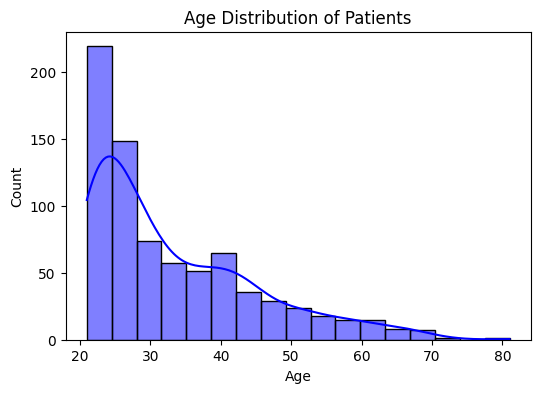

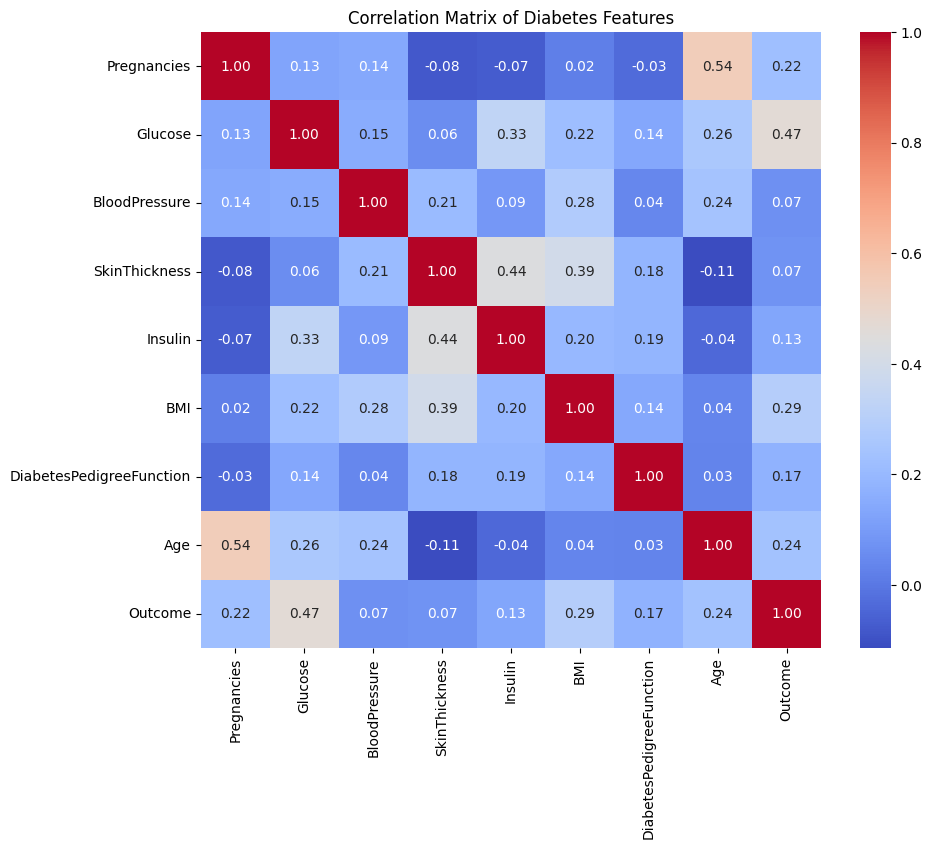

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(dataset['Age'], kde=True, color='blue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Diabetes Features')
plt.show()

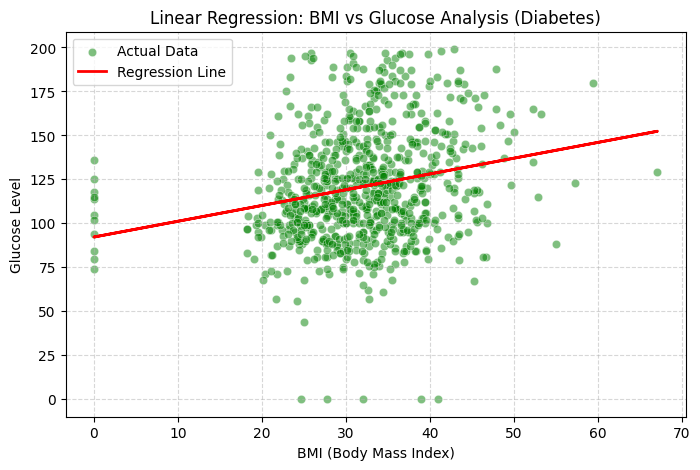

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

X_db = dataset[['BMI']]
y_db = dataset['Glucose']

lr_db = LinearRegression()
lr_db.fit(X_db, y_db)
y_db_pred = lr_db.predict(X_db)

plt.figure(figsize=(8, 5))

sns.scatterplot(x=dataset['BMI'], y=dataset['Glucose'], color='green', alpha=0.5, label='Actual Data')
plt.plot(dataset['BMI'], y_db_pred, color='red', linewidth=2, label='Regression Line')

plt.title('Linear Regression: BMI vs Glucose Analysis (Diabetes)')
plt.xlabel('BMI (Body Mass Index)')
plt.ylabel('Glucose Level')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [11]:
!pip install streamlit localtunnel -q
!streamlit run app.py & npx localtunnel --port 8501

ERROR: Ignored the following versions that require a different python version: 0.55.2 Requires-Python <3.5
ERROR: Could not find a version that satisfies the requirement localtunnel (from versions: none)
ERROR: No matching distribution found for localtunnel
/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://cuddly-parrots-appear.loca.lt
^C


In [12]:
from google.colab import output
import subprocess
import time

proc = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.address", "127.0.0.1"])

time.sleep(5)

output.serve_kernel_port_as_iframe(8501, height="800")

FileNotFoundError: [Errno 2] No such file or directory: 'streamlit'